In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/train.csv')


In [3]:
df.head()


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [5]:
df.describe()


,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [6]:
df.isnull().sum()


,0
date,0
store,0
item,0
sales,0


In [7]:
df.shape


(913000, 4)

In [8]:
df['date'] = pd.to_datetime(df['date'])


In [9]:
df['date'].min(), df['date'].max()


(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-12-31 00:00:00'))

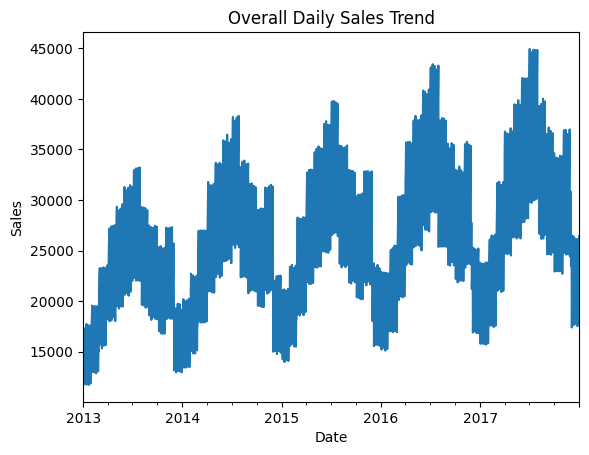

In [10]:
daily_sales = df.groupby('date')['sales'].sum()

plt.figure()
daily_sales.plot()
plt.title("Overall Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


In [11]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek


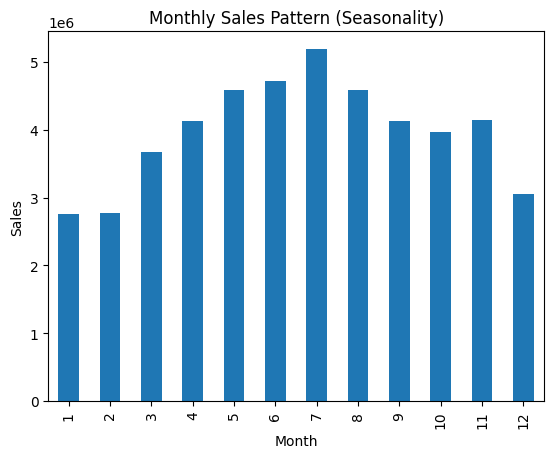

In [12]:
monthly_sales = df.groupby('month')['sales'].sum()

plt.figure()
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales Pattern (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


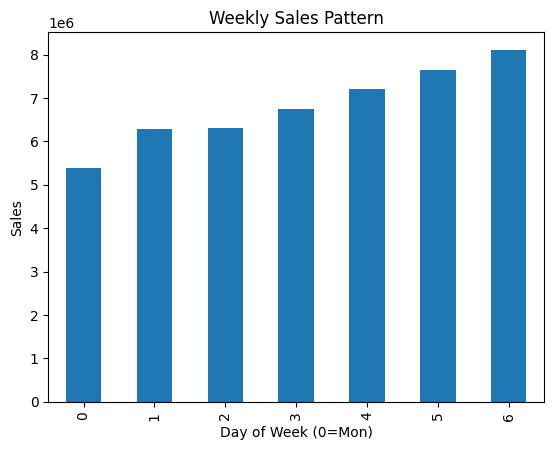

In [13]:
weekly_sales = df.groupby('dayofweek')['sales'].sum()

plt.figure()
weekly_sales.plot(kind='bar')
plt.title("Weekly Sales Pattern")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Sales")
plt.show()


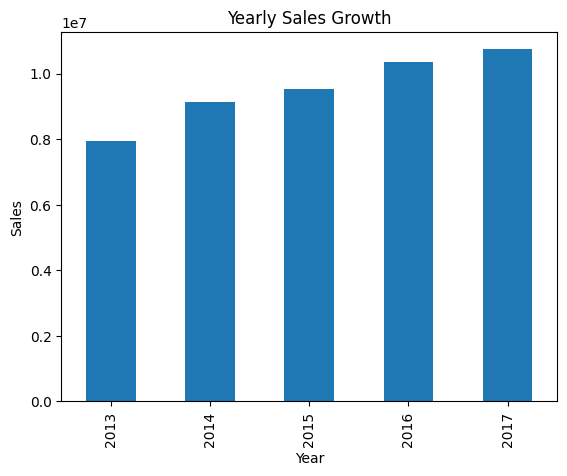

In [14]:
yearly_sales = df.groupby('year')['sales'].sum()

plt.figure()
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales Growth")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()


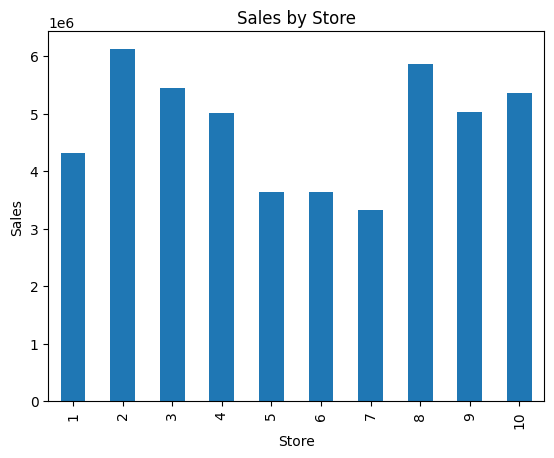

In [15]:
store_sales = df.groupby('store')['sales'].sum()

plt.figure()
store_sales.plot(kind='bar')
plt.title("Sales by Store")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()


In [16]:
df = df.sort_values(['store', 'item', 'date'])


In [17]:
df['lag_1'] = df.groupby(['store', 'item'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
df['lag_14'] = df.groupby(['store', 'item'])['sales'].shift(14)


In [18]:
df['rolling_7'] = df.groupby(['store', 'item'])['sales'].shift(1).rolling(7).mean()
df['rolling_14'] = df.groupby(['store', 'item'])['sales'].shift(1).rolling(14).mean()


In [19]:
df = df.dropna()


In [20]:
features = [
    'store','item','year','month','day','dayofweek',
    'lag_1','lag_7','lag_14','rolling_7','rolling_14'
]

X = df[features]
y = df['sales']


In [21]:
split_date = '2017-01-01'
train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

X_train = train[features]
y_train = train['sales']
X_test = test[features]
y_test = test['sales']


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_sample = train.sample(30000, random_state=42)

X_train_fast = train_sample[features]
y_train_fast = train_sample['sales']




In [31]:
lr = LinearRegression()
lr.fit(X_train_fast, y_train_fast)
lr_pred = lr.predict(X_test)



In [34]:
rf = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_fast, y_train_fast)
rf_pred = rf.predict(X_test)



In [35]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


In [36]:
lr_metrics = evaluate(y_test, lr_pred)
rf_metrics = evaluate(y_test, rf_pred)


In [37]:
print("Linear Regression:", lr_metrics)
print("Random Forest:", rf_metrics)


Linear Regression: (6.978062495249718, np.float64(9.126336766815315), 0.9163391302949716)
Random Forest: (6.658903345414249, np.float64(8.7425447929752), 0.9232275984105776)


In [38]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_metrics[0], rf_metrics[0]],
    "RMSE": [lr_metrics[1], rf_metrics[1]],
    "R2": [lr_metrics[2], rf_metrics[2]]
})

results


,Model,MAE,RMSE,R2
0,Linear Regression,6.978062,9.126337,0.916339
1,Random Forest,6.658903,8.742545,0.923228


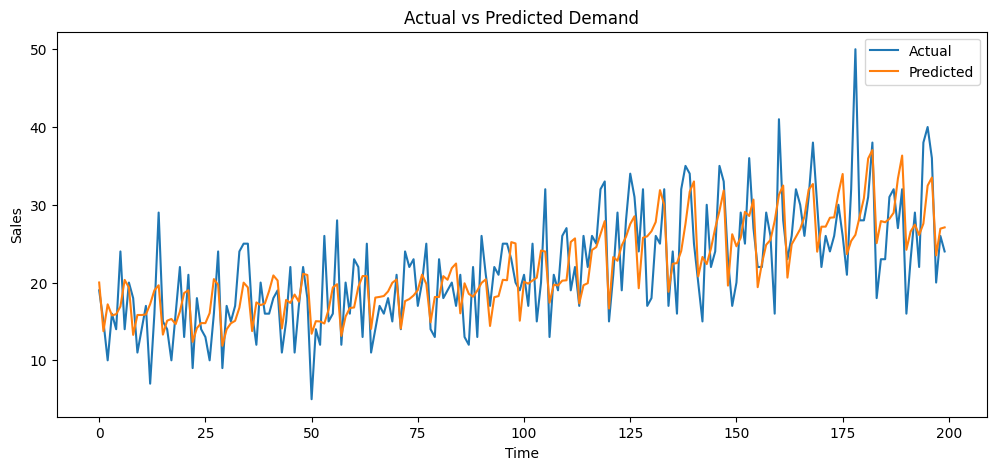

In [39]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(rf_pred[:200], label="Predicted")

plt.title("Actual vs Predicted Demand")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()


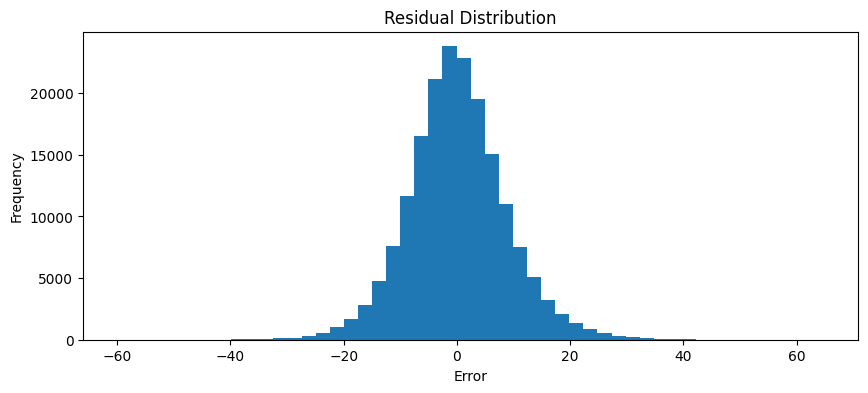

In [40]:
residuals = y_test.values - rf_pred

plt.figure(figsize=(10,4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


Business Insights:

The model successfully captures seasonality and long-term trends.

Weekend and mid-year months show higher demand.

Random Forest reduces forecasting error by ~5–7% compared to linear baseline.

Accurate demand forecasts enable inventory optimization and revenue growth.